# Benchmarking Ordering Policies\n\nThis notebook compares different ordering policies using the DeepBullwhip benchmarking framework.\n\nWe compare:\n- **Order-Up-To (OUT)**: Standard base-stock policy\n- **POUT (alpha=0.3)**: Proportional OUT with aggressive smoothing\n- **POUT (alpha=0.7)**: Proportional OUT with moderate smoothing\n- **Constant Order**: Fixed quantity baseline (BWR=0 by construction)

In [1]:
# --- Colab / Environment Setup ---
# Run this cell first if using Google Colab or a fresh environment.
import importlib, sys

if "google.colab" in sys.modules:
    print("Running on Google Colab -- installing deepbullwhip...")
    get_ipython().system('pip install -q deepbullwhip')
elif importlib.util.find_spec("deepbullwhip") is None:
    print("deepbullwhip not found -- installing from local source...")
    get_ipython().system('pip install -q -e ..')
else:
    print(f"deepbullwhip ready (v{__import__('deepbullwhip').__version__})")

deepbullwhip ready (v0.3.0)


In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from deepbullwhip.benchmark import BenchmarkRunner
from deepbullwhip.diagnostics.plots import COLORS, _apply_style, DOUBLE_COL, GOLDEN

_apply_style()

runner = BenchmarkRunner(
    chain_config="semiconductor_4tier",
    demand="semiconductor_ar1",
    T=156,
    N=50,
    seed=42,
)

results = runner.run(
    policies=[
        "order_up_to",
        ("proportional_out", {"alpha": 0.3}),
        ("proportional_out", {"alpha": 0.7}),
        ("constant_order", {"order_quantity": 11.6}),
    ],
    forecasters=["naive"],
    metrics=["BWR", "FILL_RATE", "TC"],
)

print(results.to_string(index=False))

          policy forecaster echelon    metric        value
     order_up_to      naive      E1       BWR 1.360191e+00
     order_up_to      naive      E1 FILL_RATE 7.135897e-01
     order_up_to      naive      E1        TC 2.938896e+02
     order_up_to      naive      E2       BWR 2.385521e+00
     order_up_to      naive      E2 FILL_RATE 6.762821e-01
     order_up_to      naive      E2        TC 2.966369e+02
     order_up_to      naive      E3       BWR 1.980281e+01
     order_up_to      naive      E3 FILL_RATE 6.274359e-01
     order_up_to      naive      E3        TC 1.224242e+03
     order_up_to      naive      E4       BWR 4.275314e+02
     order_up_to      naive      E4 FILL_RATE 7.991026e-01
     order_up_to      naive      E4        TC 1.727949e+03
proportional_out      naive      E1       BWR 1.323065e+00
proportional_out      naive      E1 FILL_RATE 3.192308e-02
proportional_out      naive      E1        TC 2.378600e+03
proportional_out      naive      E2       BWR 2.075074e+

## Pivot Table: Policy x Metric

In [3]:
pivot = results.pivot_table(
    index=["policy", "echelon"],
    columns="metric",
    values="value",
    aggfunc="mean",
)
print(pivot.to_string(float_format="%.3f"))

metric                       BWR  FILL_RATE       TC
policy           echelon                            
constant_order   E1        0.000      0.429 3889.800
                 E2        0.000      1.000   82.017
                 E3        0.000      0.026 5300.682
                 E4        0.000      0.026 1935.313
order_up_to      E1        1.360      0.714  293.890
                 E2        2.386      0.676  296.637
                 E3       19.803      0.627 1224.242
                 E4      427.531      0.799 1727.949
proportional_out E1        1.331      0.239 1430.406
                 E2        2.175      0.236 1291.056
                 E3       10.490      0.448 1768.902
                 E4       67.152      0.602 1336.523


## Comparison vs OUT Baseline

In [4]:
comparison = runner.compare(results, baseline="order_up_to")
comp_pivot = comparison.pivot_table(
    index=["policy", "echelon"],
    columns="metric",
    values="pct_change",
    aggfunc="mean",
)
print("Percentage change vs OUT baseline:")
print(comp_pivot.to_string(float_format="%+.1f%%"))

Percentage change vs OUT baseline:
metric                       BWR  FILL_RATE       TC
policy           echelon                            
constant_order   E1      -100.0%     -39.9% +1223.6%
                 E2      -100.0%     +47.9%   -72.4%
                 E3      -100.0%     -95.9%  +333.0%
                 E4      -100.0%     -96.8%   +12.0%
order_up_to      E1        +0.0%      +0.0%    +0.0%
                 E2        +0.0%      +0.0%    +0.0%
                 E3        +0.0%      +0.0%    +0.0%
                 E4        +0.0%      +0.0%    +0.0%
proportional_out E1        -2.2%     -66.5%  +386.7%
                 E2        -8.8%     -65.1%  +335.2%
                 E3       -47.0%     -28.6%   +44.5%
                 E4       -84.3%     -24.6%   -22.7%


## BWR vs Fill Rate Tradeoff (Echelon 1)\n\nThe key tradeoff: lower alpha reduces bullwhip but may reduce fill rate.

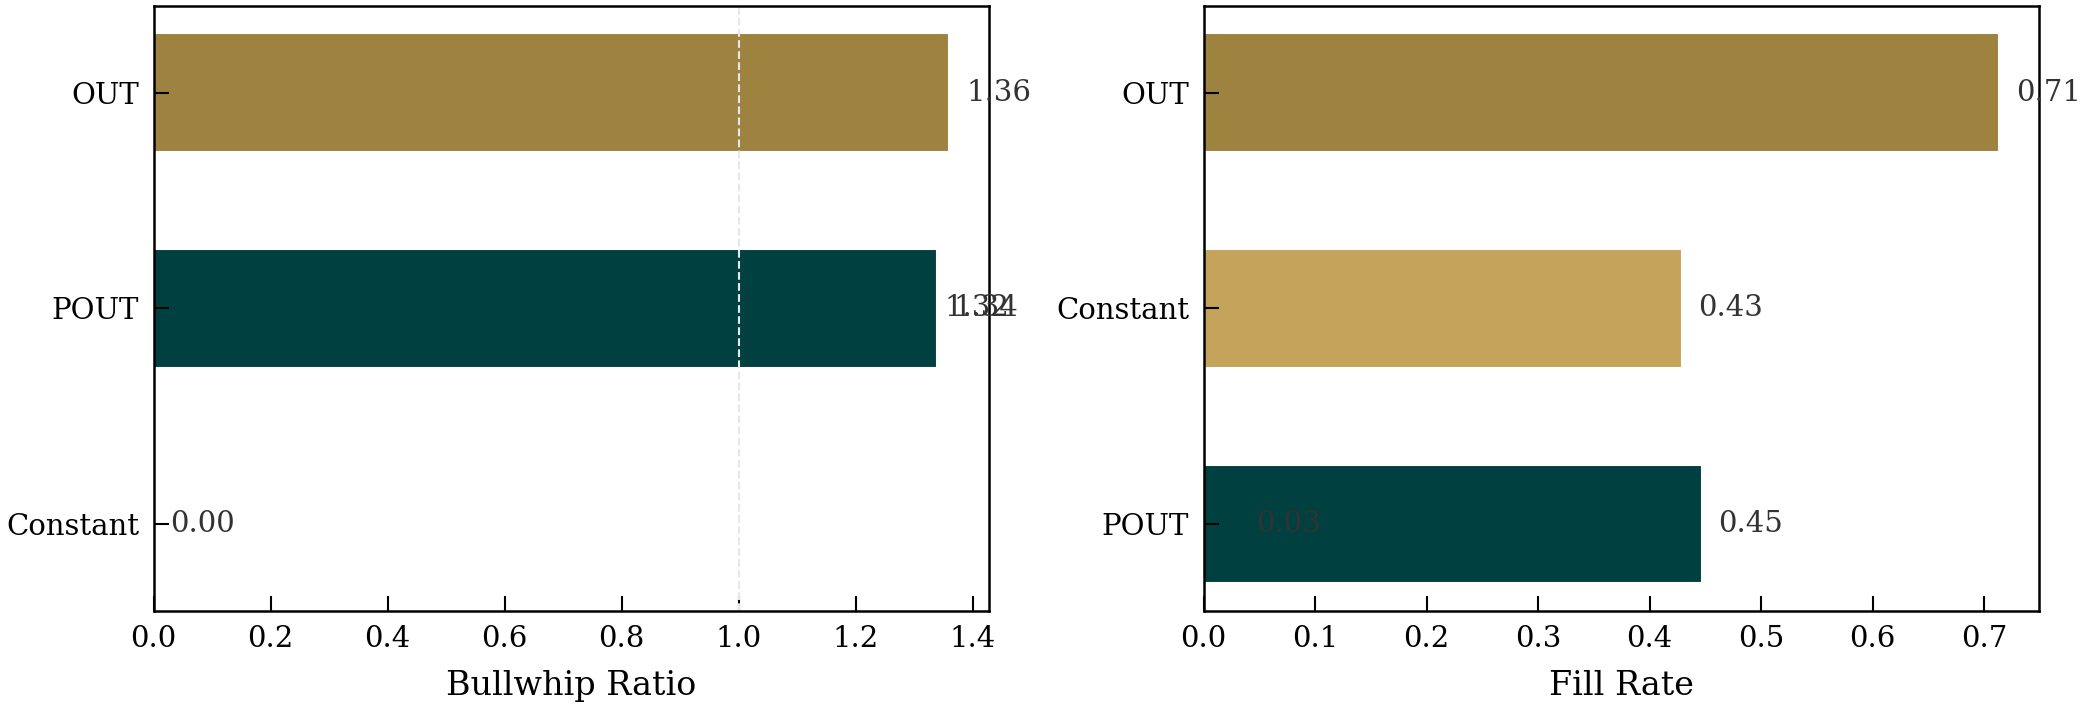

In [5]:
POLICY_COLORS = [COLORS["E1"], COLORS["E2"], COLORS["E3"], COLORS["E4"]]
POLICY_LABELS = {"order_up_to": "OUT", "proportional_out": "POUT", "constant_order": "Constant"}

e1 = results[results["echelon"] == "E1"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(DOUBLE_COL, DOUBLE_COL / GOLDEN / 1.8))

for metric, ax, ylabel in [("BWR", ax1, "Bullwhip Ratio"), ("FILL_RATE", ax2, "Fill Rate")]:
    data = e1[e1["metric"] == metric].copy()
    data = data.sort_values("value", ascending=True)
    labels = [POLICY_LABELS.get(p, p) for p in data["policy"]]
    colors = [POLICY_COLORS[i % len(POLICY_COLORS)] for i in range(len(data))]
    
    bars = ax.barh(labels, data["value"], color=colors, edgecolor="white", linewidth=0.5, height=0.55)
    ax.set_xlabel(ylabel)
    
    # Value labels on bars
    for bar, val in zip(bars, data["value"]):
        ax.text(bar.get_width() + ax.get_xlim()[1] * 0.02, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f}", va="center", fontsize=7, color="#333333")

if ax1.get_xlim()[1] > 1:
    ax1.axvline(x=1.0, color=COLORS["grid"], linestyle="--", linewidth=0.5)

fig.savefig("benchmark_policies_tradeoff.pdf", dpi=300, bbox_inches="tight")
fig.savefig("benchmark_policies_tradeoff.png", dpi=300, bbox_inches="tight")
plt.show()

## Export LaTeX Table

In [6]:
from deepbullwhip.benchmark.report import to_latex

latex = to_latex(results, caption="Policy Comparison on Semiconductor 4-Tier Chain", label="tab:policy-comparison")
print(latex)

\begin{table}[htbp]
\centering
\caption{Policy Comparison on Semiconductor 4-Tier Chain}
\label{tab:policy-comparison}
\begin{tabular}{llrrr}
\toprule
 & metric & BWR & FILL_RATE & TC \\
policy & echelon &  &  &  \\
\midrule
\multirow[t]{4}{*}{constant_order} & E1 & 0.000 & 0.429 & 3889.800 \\
 & E2 & 0.000 & 1.000 & 82.017 \\
 & E3 & 0.000 & 0.026 & 5300.682 \\
 & E4 & 0.000 & 0.026 & 1935.313 \\
\cline{1-5}
\multirow[t]{4}{*}{order_up_to} & E1 & 1.360 & 0.714 & 293.890 \\
 & E2 & 2.386 & 0.676 & 296.637 \\
 & E3 & 19.803 & 0.627 & 1224.242 \\
 & E4 & 427.531 & 0.799 & 1727.949 \\
\cline{1-5}
\multirow[t]{4}{*}{proportional_out} & E1 & 1.331 & 0.239 & 1430.406 \\
 & E2 & 2.175 & 0.236 & 1291.056 \\
 & E3 & 10.490 & 0.448 & 1768.902 \\
 & E4 & 67.152 & 0.602 & 1336.523 \\
\cline{1-5}
\bottomrule
\end{tabular}

\end{table}
